<a href="https://colab.research.google.com/github/Arashimaal/dsp-audio-processing/blob/main/Arash_DSP_Coursework.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Set up dependencies

In [1]:
try:
    import google.colab
    import subprocess
    import os.path
    p = subprocess.run(['git', 'rev-parse', '--is-inside-work-tree'], stdout=subprocess.PIPE, universal_newlines=True)
    if p.stdout == 'true\n':
        !git pull
    else:
        if not os.path.isdir('city_dsp_ap'):
            !git clone --depth 1 -q https://github.com/tweyde/city_dsp_ap.git
        %cd city_dsp_ap
except:
    %cd city_dsp_ap

/content/city_dsp_ap


In [2]:
import numpy as np
from scipy import fft, signal
from scipy.io import wavfile
import matplotlib.pyplot as plt
from skimage.transform import rotate
from skimage.util import random_noise
from IPython.display import Audio, display

In [3]:
import scipy as sp
sp.__version__

'1.16.3'

## Controllable delay line (UG) or filter (PG)

You will need to create a function that applies the desired effect to any input signal, where the effect can be dynamically modified by a control signal. The functions only need to be implemented for offline use, so you don't need to be handle input buffers of arbitrary sizes like in lab 6. It suffices to use a single for loop to run over all samples of the input and control signals, and create the output sample-by-sample.


In [4]:
%ls audio/*.wav

audio/20-16000HzExp5sec.wav  audio/carrier.wav*  audio/rockA.wav
audio/20-16000HzLin5sec.wav  audio/clavinet.wav  audio/rockB.wav


#### UG

Program a controllable delay line. Mix the output with the original input to create a flanging effect. Use the control signal to vary the amount of delay between zero and a maximum value (1 millisecond would be a good default for this, use the samplerate to calculate how much samples this is).

The control signal should be a sine of 0.2Hz (you can experiment with other frequencies). Create one of the required length yourself. Any signal should work as input signal. You can learn how to [upload your own files](https://colab.research.google.com/notebooks/io.ipynb) into Google Colab, but the easiest is to use one the 'clavinet.wav' file available in the `audio` directory. If you're loading a stereo file, it is allowed to mix it down into a single mono channel before passing it to the effect to simplify processing.

#### PG
Program a controllable FIR filter, i.e. a filter that changes its characteristics over time in response to a control signal. Apply the filter to the signal by implementing a convolution with the filter coefficients in a loop over the samples, just like in lab 7. In order to make the filter respond to the control signal, directly manipulate the filter characteristics in the filter design function [`firls`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.firls.html) and call it for every iteration.

The control signal should be the power of the audio signal (you can experiment with other frequencies), which needs to be low-pass filtered for good results (why is that?). Any signal should work as input signal. You can learn how to [upload your own files](https://colab.research.google.com/notebooks/io.ipynb) into Google Colab, but the easiest is to use one the 'clavinet.wav' file available in the `audio` directory. If you're loading a stereo file, it is allowed to mix it down into a single mono channel before passing it to the effect to simplify processing.


Sample rate: 44100 Hz
Max delay: 132 samples
Max delay in milliseconds: 2.993 ms


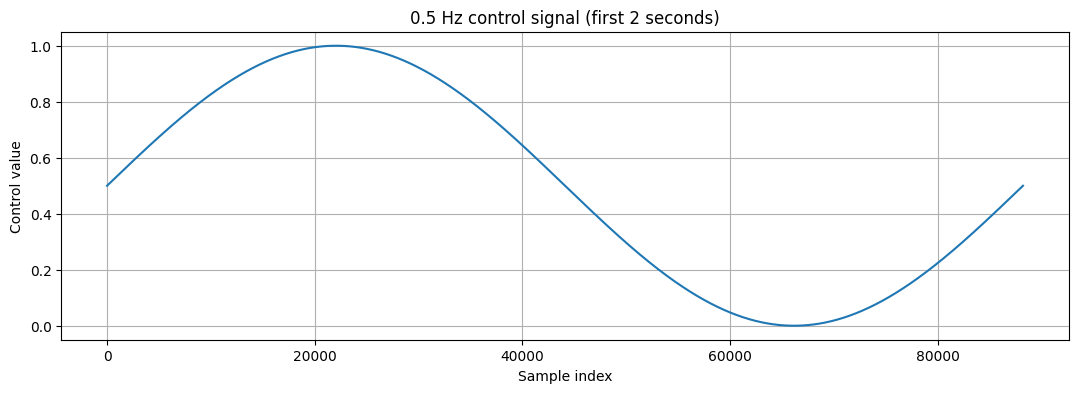

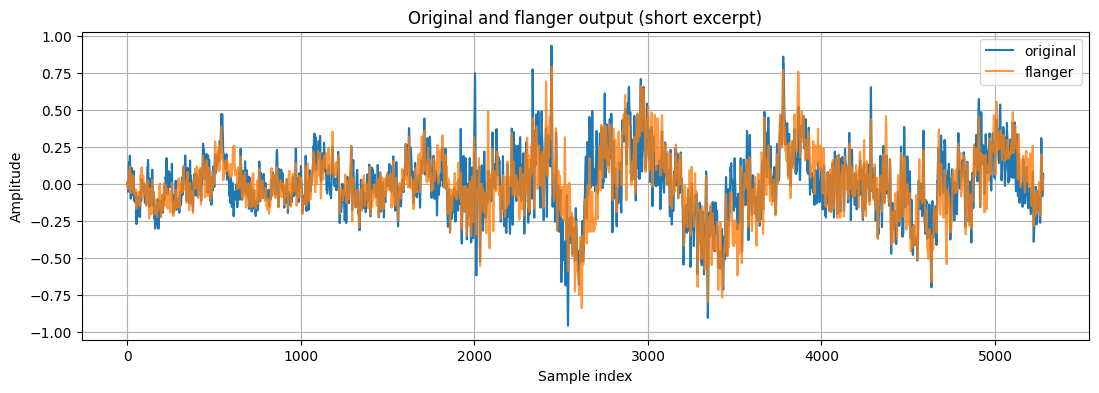

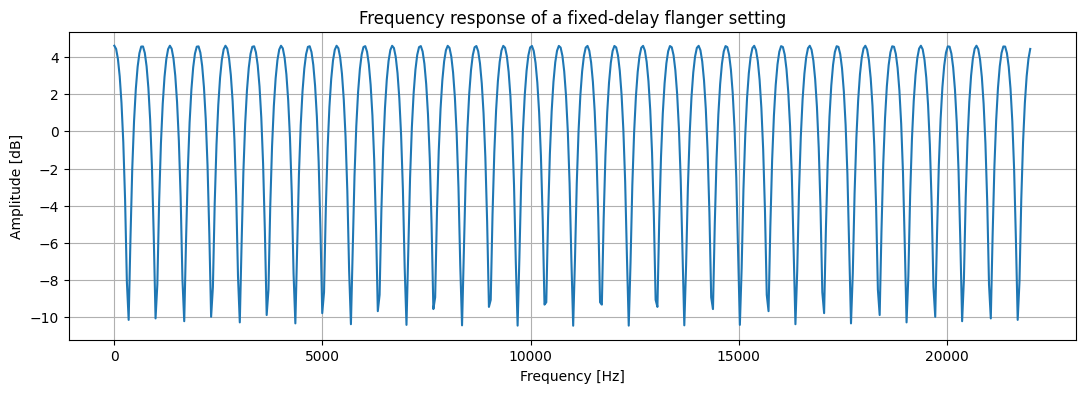

In [5]:
input_filename = 'audio/rockB.wav' #rockB song (12seconds)

samplerate, samples = wavfile.read(input_filename)

samples = samples.astype(np.float64)
if samples.ndim > 1:
    samples = np.mean(samples, axis=1)

peak = np.max(np.abs(samples))
if peak > 0:
    samples = samples / peak


def make_control_signal(num_samples, samplerate, lfo_hz=0.5):
    time = np.arange(num_samples) / samplerate
    return 0.5 * (1 + np.sin(2 * np.pi * lfo_hz * time))


def flanger_delay(samples, samplerate, control_signal, max_delay_ms=3.0, dry=0.8, wet=0.8):
    max_delay_samples = max(1, int(round(max_delay_ms * 1e-3 * samplerate)))
    output = np.zeros_like(samples, dtype=np.float64)

    for n in range(len(samples)):
        current_delay = 1 + int(round(control_signal[n] * (max_delay_samples - 1)))
        delayed_sample = 0.0
        if n - current_delay >= 0:
            delayed_sample = samples[n - current_delay]
        output[n] = dry * samples[n] + wet * delayed_sample

    peak = np.max(np.abs(output))
    if peak > 0:
        output = output / peak

    return output, max_delay_samples


def plot_comb_response(delay_samples, wet_gain, samplerate):
    b = np.zeros(delay_samples + 1)
    b[0] = 1.0
    b[-1] = wet_gain
    w, h = signal.freqz(b, [1])
    freqs = w / (2 * np.pi) * samplerate

    plt.figure(figsize=(13, 4))
    plt.plot(freqs, 20 * np.log10(np.maximum(np.abs(h), 1e-8)))
    plt.title('Frequency response of a fixed-delay flanger setting')
    plt.xlabel('Frequency [Hz]')
    plt.ylabel('Amplitude [dB]')
    plt.grid(True)
    plt.show()


control_signal = make_control_signal(len(samples), samplerate, lfo_hz=0.5)
flanger_output, max_delay_samples = flanger_delay(
    samples,
    samplerate,
    control_signal,
    max_delay_ms=3.0,
    dry=0.8,
    wet=0.8
)

print(f'Sample rate: {samplerate} Hz')
print(f'Max delay: {max_delay_samples} samples')
print(f'Max delay in milliseconds: {1000 * max_delay_samples / samplerate:.3f} ms')

wavfile.write(
    'ug_task1_flanger_output.wav',
    samplerate,
    np.int16(np.clip(flanger_output, -1.0, 1.0) * 32767)
)

display(Audio(samples, rate=samplerate))
display(Audio(flanger_output, rate=samplerate))

plt.figure(figsize=(13, 4))
control_plot_len = min(len(control_signal), int(2 * samplerate))
plt.plot(control_signal[:control_plot_len])
plt.title('0.5 Hz control signal (first 2 seconds)')
plt.xlabel('Sample index')
plt.ylabel('Control value')
plt.grid(True)
plt.show()

plt.figure(figsize=(13, 4))
excerpt_len = min(len(samples), max_delay_samples * 40)
plt.plot(samples[:excerpt_len], label='original')
plt.plot(flanger_output[:excerpt_len], label='flanger', alpha=0.8)
plt.title('Original and flanger output (short excerpt)')
plt.xlabel('Sample index')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)
plt.show()

fixed_delay = max(1, max_delay_samples // 2)
plot_comb_response(fixed_delay, wet_gain=0.7, samplerate=samplerate)

## Digit recognition (UG & PG)

In this part, you're going to use images of handwritten digits ranging from 0 to 9. They are split in a training set and a test set and stored as text files in `data/digits-training.txt` and `data/digits-test.txt`.

In [6]:
%ls data/digits-*.txt

data/digits-test.txt*  data/digits-training.txt*


In [7]:
from itertools import islice
import re

def read_digit_pixels_and_labels(path):
    with open(path) as f:
        header = list(islice(f, 21))
        pixel_height = [int(x[1]) for x in map(lambda r: re.match('entheight = (\d+)', r), header) if x][0]
        num_digits = [int(x[1]) for x in map(lambda r: re.match('ntot = (\d+)', r), header) if x][0]
        digit_pixels = []
        labels = []
        for _ in range(num_digits):
            chunk = list(islice(f, pixel_height+1))
            digit_pixels.append(np.loadtxt(chunk[:-1]))
            labels.append(int(chunk[-1]))
    return digit_pixels, labels

<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:8: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_6957/3536710807.py:7: SyntaxWarning: invalid escape sequence '\d'
  pixel_height = [int(x[1]) for x in map(lambda r: re.match('entheight = (\d+)', r), header) if x][0]
/tmp/ipykernel_6957/3536710807.py:8: SyntaxWarning: invalid escape sequence '\d'
  num_digits = [int(x[1]) for x in map(lambda r: re.match('ntot = (\d+)', r), header) if x][0]


Since the text files have a custom format, a loader function `read_digit_pixels_and_labels` is provided.

In [8]:
training_digits, training_labels = read_digit_pixels_and_labels('data/digits-training.txt')
test_digits, test_labels = read_digit_pixels_and_labels('data/digits-test.txt')

In [9]:
len(training_digits), len(training_labels), len(test_digits), len(test_labels)

(1934, 1934, 943, 943)

All digits and their associated labels have now been read into lists, so we can use list indexing to access them and, for instance, display them as below.

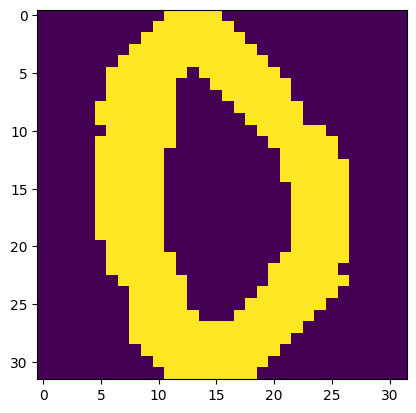

Image of digit 0


In [10]:
index = 1
plt.figure()
plt.imshow(training_digits[index])
plt.show()
print('Image of digit {}'.format(training_labels[index]))

Using this data, your task is to:

1. Create a function for comparing each test image with the collection of training images, using the correlation with each training image without offset (i.e. calculate the sum of the element-wise multiplied images).
2. Estimate the most likely label for each test image by matching with the training image that has maximal correlation.
3. Estimate the accuracy of your system, as a fraction of the correctly estimated test labels over the total number of test images.
4. Use the two-dimensional correlation function [`signal.correlate2d`](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.correlate2d.html) to find the best match over all image offsets. For efficiency you can use a subset of the training images, or calculate an average of the training images.
5. Implement variants of the digit recognition system, e.g.
    - use the negatives of the training and test images instead of the positive images
    - use images that are slightly rotated in your training set (using [`rotate`](https://scikit-image.org/docs/dev/api/skimage.transform.html#skimage.transform.rotate) from the `scikit-image.transform` library)
    - use images with some noise added in your training set (using [`random_noise`](https://scikit-image.org/docs/dev/api/skimage.util.html#random-noise) from the `scikit-image.util` library)
6. Report the accuracy of the new system and compare with the accuracy of the previous systems.
7. In the written report, discuss and reason about the different performances of your classifiers.

baseline_no_offset: 0.9014
offset_template_correlate2d: 0.8929
negative_templates: 0.7911
rotated_templates: 0.8812
noisy_templates: 0.8791


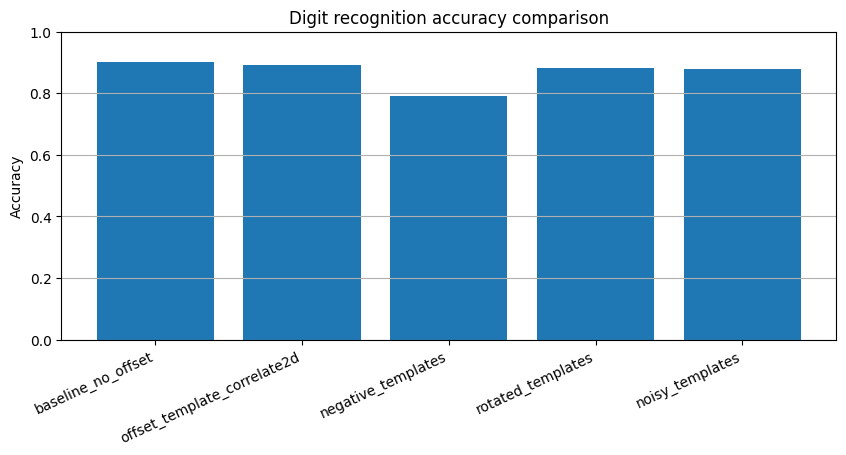

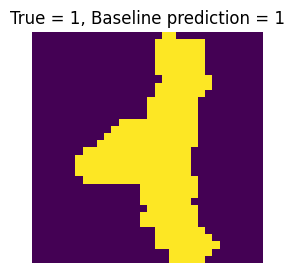

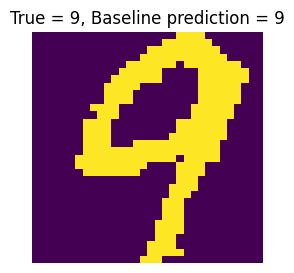

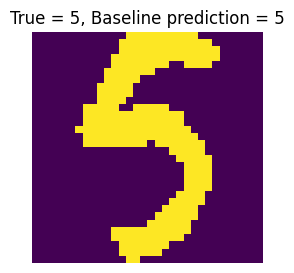

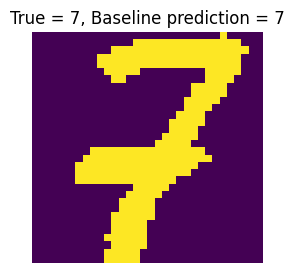

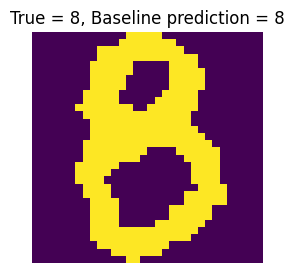

In [11]:
np.random.seed(0)


def normalise_image(img):
    img = np.asarray(img, dtype=np.float64)
    img_min = img.min()
    img_max = img.max()
    if img_max > img_min:
        return (img - img_min) / (img_max - img_min)
    return np.zeros_like(img, dtype=np.float64)


def images_to_matrix(images):
    return np.stack([img.reshape(-1) for img in images], axis=0)


def accuracy_from_scores(score_matrix, candidate_labels, true_labels):
    predicted_indices = np.argmax(score_matrix, axis=1)
    predicted_labels = candidate_labels[predicted_indices]
    accuracy = np.mean(predicted_labels == true_labels)
    return predicted_labels, accuracy


def make_average_templates(images, labels):
    templates = []
    template_labels = []

    for digit in range(10):
        digit_images = [img for img, label in zip(images, labels) if int(label) == digit]
        template = normalise_image(np.mean(np.stack(digit_images, axis=0), axis=0))
        templates.append(template)
        template_labels.append(digit)

    return templates, np.array(template_labels, dtype=int)


def offset_template_predictions(test_images, template_images, template_labels):
    predictions = []

    for test_img in test_images:
        best_score = -np.inf
        best_label = -1

        for template_img, template_label in zip(template_images, template_labels):
            score = np.max(signal.correlate2d(test_img, template_img, mode='full'))
            if score > best_score:
                best_score = score
                best_label = int(template_label)

        predictions.append(best_label)

    return np.array(predictions, dtype=int)


def negative_images(images):
    return [1.0 - img for img in images]


def make_rotated_template_bank(template_images, template_labels, angles=(-8, 0, 8)):
    rotated_images = []
    rotated_labels = []

    for template_img, template_label in zip(template_images, template_labels):
        for angle in angles:
            if angle == 0:
                rotated = template_img
            else:
                rotated = rotate(
                    template_img,
                    angle=angle,
                    resize=False,
                    preserve_range=True,
                    mode='edge'
                )
            rotated_images.append(normalise_image(rotated))
            rotated_labels.append(int(template_label))

    return rotated_images, np.array(rotated_labels, dtype=int)


def make_noisy_template_bank(template_images, template_labels, copies=2, variance=0.01):
    noisy_images = []
    noisy_labels = []

    for template_img, template_label in zip(template_images, template_labels):
        noisy_images.append(template_img)
        noisy_labels.append(int(template_label))
        for _ in range(copies):
            noisy = random_noise(template_img, mode='gaussian', var=variance)
            noisy_images.append(normalise_image(noisy))
            noisy_labels.append(int(template_label))

    return noisy_images, np.array(noisy_labels, dtype=int)


train_images = [normalise_image(img) for img in training_digits]
test_images = [normalise_image(img) for img in test_digits]
train_labels_array = np.array(training_labels, dtype=int)
test_labels_array = np.array(test_labels, dtype=int)

train_matrix = images_to_matrix(train_images)
test_matrix = images_to_matrix(test_images)
baseline_scores = test_matrix @ train_matrix.T
baseline_predictions, baseline_accuracy = accuracy_from_scores(
    baseline_scores,
    train_labels_array,
    test_labels_array
)

template_images, template_labels = make_average_templates(train_images, train_labels_array)

offset_predictions = offset_template_predictions(test_images, template_images, template_labels)
offset_accuracy = np.mean(offset_predictions == test_labels_array)

# Negative Images
negative_template_images = negative_images(template_images)
negative_test_images = negative_images(test_images)
negative_scores = images_to_matrix(negative_test_images) @ images_to_matrix(negative_template_images).T
negative_predictions, negative_accuracy = accuracy_from_scores(
    negative_scores,
    template_labels,
    test_labels_array
)

# Rotated Templates
rotated_template_images, rotated_template_labels = make_rotated_template_bank(
    template_images,
    template_labels,
    angles=(-8, 0, 8)
)
rotated_scores = test_matrix @ images_to_matrix(rotated_template_images).T
rotated_predictions, rotated_accuracy = accuracy_from_scores(
    rotated_scores,
    rotated_template_labels,
    test_labels_array
)

# Noisy Templates
noisy_template_images, noisy_template_labels = make_noisy_template_bank(
    template_images,
    template_labels,
    copies=2,
    variance=0.01
)
noisy_scores = test_matrix @ images_to_matrix(noisy_template_images).T
noisy_predictions, noisy_accuracy = accuracy_from_scores(
    noisy_scores,
    noisy_template_labels,
    test_labels_array
)

results = {
    'baseline_no_offset': baseline_accuracy,
    'offset_template_correlate2d': offset_accuracy,
    'negative_templates': negative_accuracy,
    'rotated_templates': rotated_accuracy,
    'noisy_templates': noisy_accuracy,
}

for name, accuracy in results.items():
    print(f'{name}: {accuracy:.4f}')

plt.figure(figsize=(10, 4))
plt.bar(results.keys(), results.values())
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Digit recognition accuracy comparison')
plt.xticks(rotation=25, ha='right')
plt.grid(axis='y')
plt.show()

for index in range(5):
    plt.figure(figsize=(3, 3))
    plt.imshow(test_images[index])
    plt.title(f'True = {test_labels_array[index]}, Baseline prediction = {baseline_predictions[index]}')
    plt.axis('off')
    plt.show()


## Time series prediction with financial data (UG & PG)

In this part, you're going to use long term US stock market data (monthly indices, dividends, earnings, etc. since 1871). Information about the data provenance and references can be found at http://www.econ.yale.edu/~shiller/data.htm (especially the 2nd paragraph). The data is available in the file `data/financial_data.csv`.

It is stored as comma-separated numerical values, with a header containing column names. Therefore we can use [`np.genfromtxt`](https://docs.scipy.org/doc/numpy/reference/generated/numpy.genfromtxt.html#numpy.genfromtxt) to read it.

In [12]:
financial = np.genfromtxt('data/financial_data.csv', delimiter=',', skip_header=2, names=True)

The result is a structured array, which means that we can access each of the columns in the table by its name. The list of all colums can be found below.

In [13]:
financial.dtype.names

('Date',
 'SP_Comp_P',
 'Dividend_D',
 'Earnings_E',
 'Consumer_Price_Index_CPI',
 'Date_Fraction',
 'Long_Interest_Rate_GS10',
 'Real_Price',
 'Real_Dividend',
 'Real_Earnings',
 'Cyclically_Adjusted_Price_Earnings_Ratio_PE10_or_CAPE')

You can access the columns using their names between square brackets, like you would for a dictionary. It's advised to store the columns you need in helper variables, to avoid long statements resulting from the long column names.

In [14]:
date = financial['Date']
real_price = financial['Real_Price']

Now you can easily use the data, for instance to plot it.

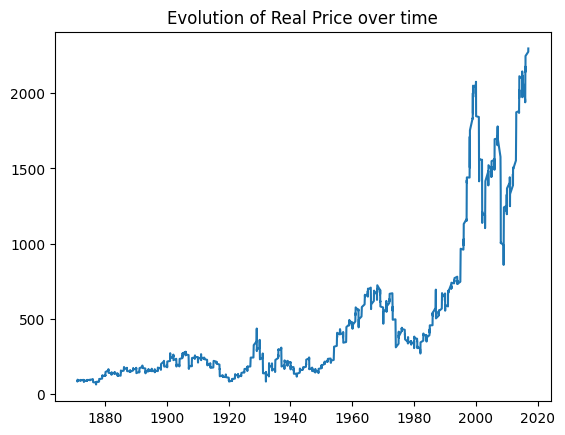

In [15]:
plt.figure()
plt.plot(date, real_price)
plt.title('Evolution of Real Price over time')
plt.show()

Using this data, your task is to:

1. Look for long term trends on a linear and log scale and de-trend the data first.
2. Calculate the FFT of the signal of interest, to estimate possible periodicities. You can use a window to avoid spectral leaking.
3. Refine your analysis by adjusting the size of the dataset (e.g. if you model annual patterns, make sure your dataset size is a multiple of 12).

In [16]:
# write your code here